In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('AIML Dataset.csv')

In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [5]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


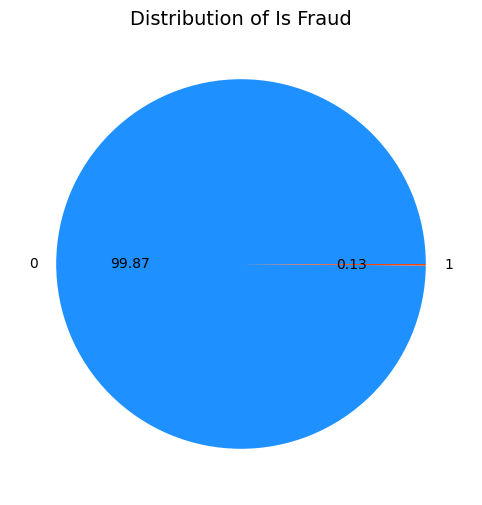

In [18]:
df['isFraud'].value_counts().plot(kind='pie', autopct='%.2f', figsize=(12,6), colors=['dodgerblue', 'orangered'])
plt.title('Distribution of Is Fraud', fontsize=14)
plt.show()

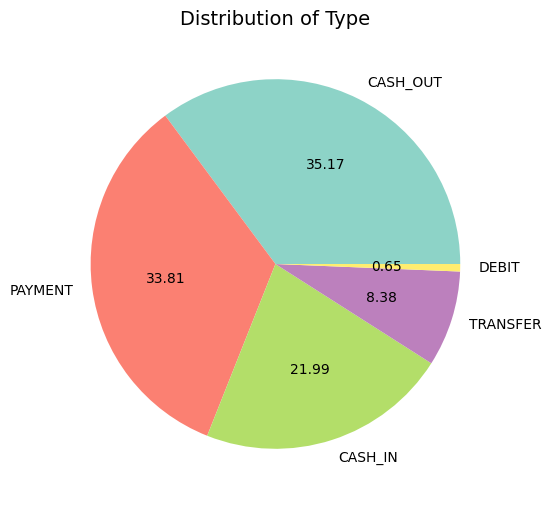

In [13]:
df['type'].value_counts().plot(kind='pie', autopct='%.2f', figsize=(12,6), cmap="Set3")
plt.title('Distribution of Type', fontsize=14)
plt.show()

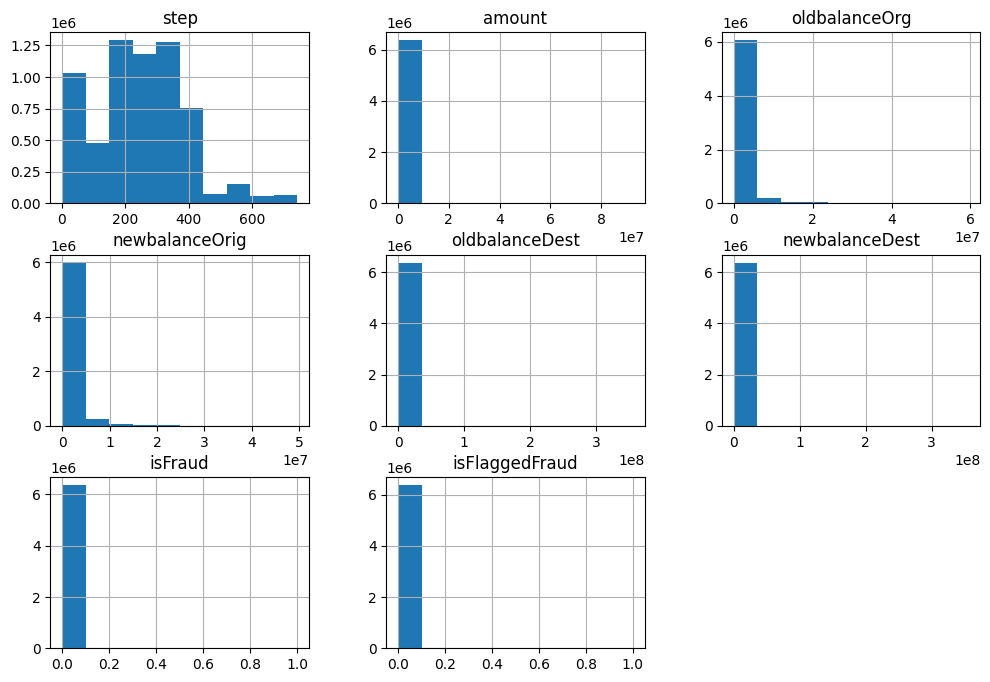

In [19]:
df.hist(figsize=(12,8))
plt.show()

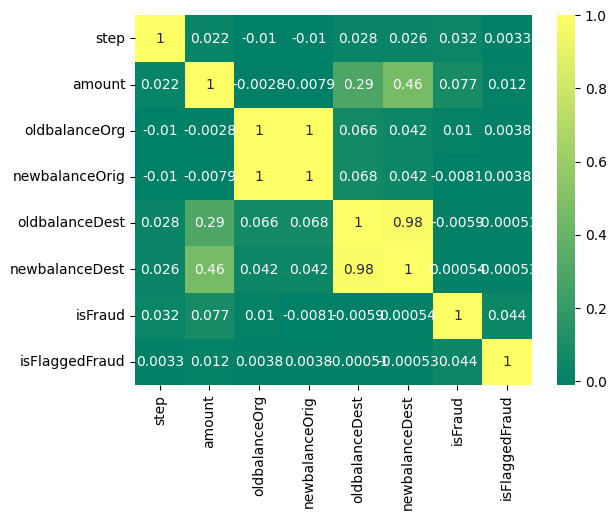

In [21]:
figsize=(9,6)
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='summer')
plt.show()

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score,confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

In [24]:
df.drop(columns=['nameOrig', 'nameDest'], inplace=True)

In [25]:
le = LabelEncoder()
df['type']  = le.fit_transform(df['type'])

In [26]:
X = df.drop('isFraud', axis=1)
y = df['isFraud']
X_train,X_test, y_train,y_test = train_test_split(X,y , test_size=0.3)

In [27]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(4453834, 8)
(4453834,)
(1908786, 8)
(1908786,)


In [28]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier()
}


 Name: Logistic Regression
 Accuracy: 1.00
 Precision Score: 0.6632653061224489


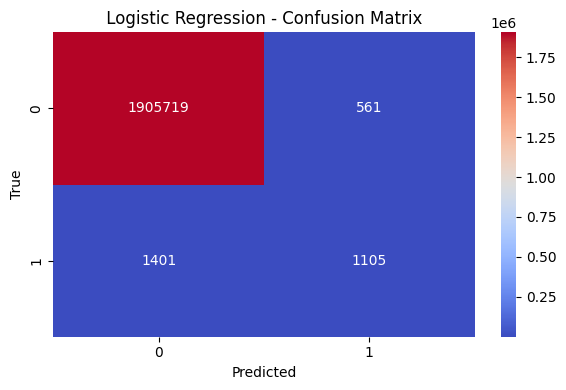


 Name: Random Forest
 Accuracy: 1.00
 Precision Score: 0.983731570920183


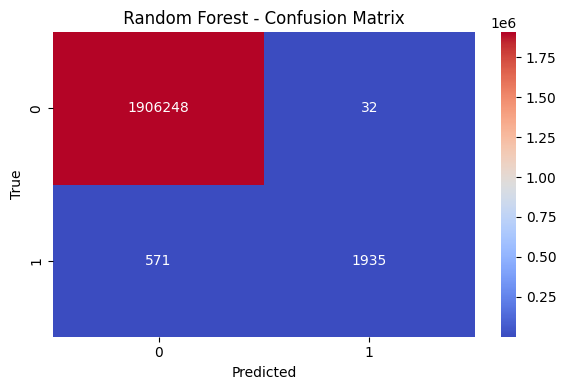


 Summary:


,Model,Accuracy,Precision
0,Logistic Regression,0.998972,0.663265
1,Random Forest,0.999684,0.983732


In [29]:
results = []
for model_names, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)

    print(f"\n Name: {model_names}")
    print(f" Accuracy: {acc:.2f}")
    print(f" Precision Score: {prec}")

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm')
    plt.title(f' {model_names} - Confusion Matrix ')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()



    results.append({
        'Model': model_names,
        'Accuracy': acc,
        'Precision': prec,
    })
    results_df = pd.DataFrame(results)

print("\n Summary:")
results_df